**🧭 Infosys Internship Project – Predicting Job Roles**

1️⃣ 📂 Importing Libraries & Loading Data    
2️⃣ 🧹 Data Cleaning & Preprocessing   
3️⃣ 🔍 Exploratory Data Analysis (EDA)    
4️⃣ 🤖 Model Building using Logistic Regression   
5️⃣ 📊 Model Evaluation & Visualization

In [ ]:
# Step 1 – Import libraries
import pandas as pd
import numpy as np
import re

# Optional display tweaks
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)



In [ ]:
# Step 2 – Load dataset
from google.colab import files


# Read dataset
df = pd.read_csv("student_job_role_dataset_500.csv")

# Basic info
print("Shape:", df.shape)
df.head()


Shape: (550, 10)


,student_name,student_id,education_qualification,skills,certifications,projects,job_role,salary_expectation,experience_years,location_preference
0,Ravi Singh,S196,MBA,"Marketing, Sales",Data Science with R,E-commerce Website,Business Analyst,900000.0,3.0,Ahmedabad
1,Sneha Patel,S080,B.Com,"Python, Excel",Java Foundations,E-commerce Website,Web Developer,450000.0,NaN,Chennai
2,Ankit Mehta,S481,B.Tech ECE,NaN,Google Data Analytics,Library Management,Business Analyst,450000.0,0.0,Mumbai
3,Rahul Verma,S110,B.Com,"Python, Excel",AI Certification,AI Chatbot,Data Scientist,450000.0,2.0,Pune
4,Neha Gupta,S281,B.Tech ECE,"Management, Excel",Excel Basics,Student Portal,AI Engineer,400000.0,4.0,Delhi


In [ ]:
# Step 3 – Clean column names
def to_snake(name):
    name = name.strip()
    name = re.sub(r"[^\w]+", "_", name)
    name = re.sub(r"_+", "_", name)
    return name.lower().strip("_")

df.columns = [to_snake(c) for c in df.columns]
print("✅ Columns standardized:", df.columns.to_list())


✅ Columns standardized: ['student_name', 'student_id', 'education_qualification', 'skills', 'certifications', 'projects', 'job_role', 'salary_expectation', 'experience_years', 'location_preference']


In [ ]:
# Step 4 – Trim spaces and fix 'nan' strings
str_cols = [c for c in df.columns if df[c].dtype == "object"]

for c in str_cols:
    df[c] = df[c].astype(str).str.strip()
    df[c] = df[c].replace({"nan": np.nan, "None": np.nan, "": np.nan})

print("✅ Cleaned text columns.")


✅ Cleaned text columns.


In [ ]:
# Step 5 – Check for missing & duplicate data
import pandas as pd

# Load dataset again as the previous cell was not executed
df = pd.read_csv("student_job_role_dataset_500.csv")

print("Missing values per column:\n", df.isna().sum())
print("\nTotal duplicate rows:", df.duplicated().sum())
if "student_id" in df.columns:
    print("Duplicate student_id count:", df["student_id"].duplicated().sum())

Missing values per column:
 student_name                0
student_id                  0
education_qualification    26
skills                     30
certifications             71
projects                   32
job_role                    0
salary_expectation         60
experience_years           93
location_preference        27
dtype: int64

Total duplicate rows: 50
Duplicate student_id count: 50


In [ ]:
# Step 6 – Remove duplicates
df = df.drop_duplicates(keep="first")

if "student_id" in df.columns:
    df = df.drop_duplicates(subset=["student_id"], keep="first")

print("✅ After duplicate removal:", df.shape)


✅ After duplicate removal: (500, 10)


In [ ]:
import pandas as pd

# Load the dataset and tell pandas what to treat as missing
df = pd.read_csv("/content/student_job_role_dataset_500.csv", na_values=['NA', 'None', ' ', ''])


In [ ]:
print("Missing values per column:\n", df.isna().sum())
print("\nTotal duplicate rows:", df.duplicated().sum())


Missing values per column:
 student_name                0
student_id                  0
education_qualification    26
skills                     30
certifications             71
projects                   32
job_role                    0
salary_expectation         60
experience_years           93
location_preference        27
dtype: int64

Total duplicate rows: 50


In [ ]:
df.fillna(df.mean(numeric_only=True), inplace=True)


In [ ]:
df.fillna(df.mode().iloc[0], inplace=True)


In [ ]:
df.drop_duplicates(inplace=True)


### Missing values After Preprocessing

In [ ]:
print("✅ Missing values per column after cleaning:\n", df.isna().sum())
print("\n✅ Total duplicate rows now:", df.duplicated().sum())


✅ Missing values per column after cleaning:
 student_name               0
student_id                 0
education_qualification    0
skills                     0
certifications             0
projects                   0
job_role                   0
salary_expectation         0
experience_years           0
location_preference        0
dtype: int64

✅ Total duplicate rows now: 0


In [ ]:
# Step 7 – Fill missing salary/experience with medians
def impute_group_median(df_, col, by):
    median_global = df_[col].median()
    med_by = df_.groupby(by)[col].median()
    return df_[col].fillna(df_[by].map(med_by)).fillna(median_global)

if "salary_expectation" in df.columns:
    df["salary_expectation"] = pd.to_numeric(df["salary_expectation"], errors="coerce")
    df["salary_expectation"] = impute_group_median(df, "salary_expectation", "job_role")

if "experience_years" in df.columns:
    df["experience_years"] = pd.to_numeric(df["experience_years"], errors="coerce")
    df["experience_years"] = impute_group_median(df, "experience_years", "job_role")
    df["experience_years"] = df["experience_years"].round().astype(int)

print("✅ Missing numeric values handled.")


✅ Missing numeric values handled.


In [ ]:
# Step 8 – Normalize text values
if "student_name" in df.columns:
    df["student_name"] = df["student_name"].str.title()

if "student_id" in df.columns:
    df["student_id"] = df["student_id"].str.upper()

print("✅ Text fields standardized.")


✅ Text fields standardized.


In [ ]:
# Step 9 – Add new feature columns
def count_skills(val):
    if pd.isna(val): return np.nan
    return len([s for s in str(val).split(",") if s.strip()])

def first_skill(val):
    if pd.isna(val): return np.nan
    return str(val).split(",")[0].strip().title()

def degree_level(val):
    if pd.isna(val): return np.nan
    v = str(val).lower()
    if "phd" in v or "ph.d" in v: return "PhD"
    if any(x in v for x in ["m.tech", "msc", "m.sc", "mca", "mba", "m."]): return "Masters"
    if any(x in v for x in ["b.tech", "bsc", "b.sc", "bca", "b.com", "b."]): return "Bachelors"
    return "Other"

df["skill_count"] = df["skills"].apply(count_skills)
df["primary_skill"] = df["skills"].apply(first_skill)
df["degree_level"] = df["education_qualification"].apply(degree_level)

print("✅ Added: skill_count, primary_skill, degree_level")
df.head()


✅ Added: skill_count, primary_skill, degree_level


,student_name,student_id,education_qualification,skills,certifications,projects,job_role,salary_expectation,experience_years,location_preference,skill_count,primary_skill,degree_level
0,Ravi Singh,S196,MBA,"Marketing, Sales",Data Science with R,E-commerce Website,Business Analyst,900000.0,3,Ahmedabad,2.0,Marketing,Masters
1,Sneha Patel,S080,B.Com,"Python, Excel",Java Foundations,E-commerce Website,Web Developer,450000.0,2,Chennai,2.0,Python,Bachelors
2,Ankit Mehta,S481,B.Tech ECE,NaN,Google Data Analytics,Library Management,Business Analyst,450000.0,0,Mumbai,NaN,NaN,Bachelors
3,Rahul Verma,S110,B.Com,"Python, Excel",AI Certification,AI Chatbot,Data Scientist,450000.0,2,Pune,2.0,Python,Bachelors
4,Neha Gupta,S281,B.Tech ECE,"Management, Excel",Excel Basics,Student Portal,AI Engineer,400000.0,4,Delhi,2.0,Management,Bachelors


In [ ]:
# Step 10 – Save cleaned dataset
df.to_csv("student_job_role_dataset_500_cleaned.csv", index=False)
print("✅ Cleaned dataset saved as 'student_job_role_dataset_500_cleaned.csv'")

# Download to your system (optional)
from google.colab import files
files.download("student_job_role_dataset_500_cleaned.csv")


✅ Cleaned dataset saved as 'student_job_role_dataset_500_cleaned.csv'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Step 11 – Verify results
print("Shape:", df.shape)
print("\nMissing values:\n", df.isna().sum())
df.head(10)


Shape: (500, 13)

Missing values:
 student_name                0
student_id                  0
education_qualification    26
skills                     27
certifications             62
projects                   28
job_role                    0
salary_expectation          0
experience_years            0
location_preference        22
skill_count                27
primary_skill              27
degree_level               26
dtype: int64


,student_name,student_id,education_qualification,skills,certifications,projects,job_role,salary_expectation,experience_years,location_preference,skill_count,primary_skill,degree_level
0,Ravi Singh,S196,MBA,"Marketing, Sales",Data Science with R,E-commerce Website,Business Analyst,900000.0,3,Ahmedabad,2.0,Marketing,Masters
1,Sneha Patel,S080,B.Com,"Python, Excel",Java Foundations,E-commerce Website,Web Developer,450000.0,2,Chennai,2.0,Python,Bachelors
2,Ankit Mehta,S481,B.Tech ECE,NaN,Google Data Analytics,Library Management,Business Analyst,450000.0,0,Mumbai,NaN,NaN,Bachelors
3,Rahul Verma,S110,B.Com,"Python, Excel",AI Certification,AI Chatbot,Data Scientist,450000.0,2,Pune,2.0,Python,Bachelors
4,Neha Gupta,S281,B.Tech ECE,"Management, Excel",Excel Basics,Student Portal,AI Engineer,400000.0,4,Delhi,2.0,Management,Bachelors
5,Meena Rani,S223,BCA,"Marketing, Sales",NaN,Customer Retention,Data Scientist,600000.0,4,NaN,2.0,Marketing,Bachelors
6,Rahul Verma,S085,BBA,"Marketing, Sales",NaN,Customer Retention,Data Scientist,500000.0,3,Mumbai,2.0,Marketing,Other
7,Ankit Mehta,S369,B.Com,"Python, Excel",Java Foundations,HR Automation,Full Stack Developer,400000.0,4,Ahmedabad,2.0,Python,Bachelors
8,Rahul Verma,S133,B.Tech CSE,"C++, HTML, CSS",NaN,Market Analysis,Data Scientist,400000.0,1,Ahmedabad,3.0,C++,Bachelors
9,Arjun Rao,S365,MCA,"Data Analytics, Power BI",Azure Fundamentals,Sales Forecasting,Software Developer,350000.0,2,Remote,2.0,Data Analytics,Masters


Done✅ Data Cleaning and Preprocessing.
Now Below you Will See the EDA Operations on the Same Data Set

2️⃣ Exploratory Data Analysis **(EDA**) Section

In [ ]:
# 0) Imports & display settings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno    # pip install missingno if not present

# display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style("whitegrid")


In [ ]:
# 1) Load dataset
df = pd.read_csv("student_job_role_dataset_500_cleaned.csv")
print("Shape:", df.shape)
df.head()


Shape: (500, 13)


,student_name,student_id,education_qualification,skills,certifications,projects,job_role,salary_expectation,experience_years,location_preference,skill_count,primary_skill,degree_level
0,Ravi Singh,S196,MBA,"Marketing, Sales",Data Science with R,E-commerce Website,Business Analyst,900000.0,3,Ahmedabad,2.0,Marketing,Masters
1,Sneha Patel,S080,B.Com,"Python, Excel",Java Foundations,E-commerce Website,Web Developer,450000.0,2,Chennai,2.0,Python,Bachelors
2,Ankit Mehta,S481,B.Tech ECE,NaN,Google Data Analytics,Library Management,Business Analyst,450000.0,0,Mumbai,NaN,NaN,Bachelors
3,Rahul Verma,S110,B.Com,"Python, Excel",AI Certification,AI Chatbot,Data Scientist,450000.0,2,Pune,2.0,Python,Bachelors
4,Neha Gupta,S281,B.Tech ECE,"Management, Excel",Excel Basics,Student Portal,AI Engineer,400000.0,4,Delhi,2.0,Management,Bachelors


In [ ]:
# Cell 2: Try common filenames, otherwise instruct user to update filename
import os
import pandas as pd

candidates = [
    "/content/student_job_role_dataset_500_cleaned.csv",
    "/content/students_data_500_cleaned.csv",
    "/content/students_data_cleaned.csv",
    "/content/student_job_role_dataset_500.csv",
    "/content/student_job_role_dataset.csv",
    "/content/student_job_role_dataset_500_eda.csv",
    "/content/student_job_role_dataset_500_cleaned (1).csv"
]

csv_path = None
for p in candidates:
    if os.path.exists(p):
        csv_path = p
        break

if csv_path is None:
    print("No candidate file found. Files in /content:")
    !ls -la /content
    raise FileNotFoundError("Please upload your cleaned CSV to Colab and set `csv_path` to its filename (or re-run after uploading).")
else:
    print("Found CSV:", csv_path)
    df = pd.read_csv(csv_path)
    print("Loaded. Shape:", df.shape)
    display(df.head())


Found CSV: /content/student_job_role_dataset_500_cleaned.csv
Loaded. Shape: (500, 13)


,student_name,student_id,education_qualification,skills,certifications,projects,job_role,salary_expectation,experience_years,location_preference,skill_count,primary_skill,degree_level
0,Ravi Singh,S196,MBA,"Marketing, Sales",Data Science with R,E-commerce Website,Business Analyst,900000.0,3,Ahmedabad,2.0,Marketing,Masters
1,Sneha Patel,S080,B.Com,"Python, Excel",Java Foundations,E-commerce Website,Web Developer,450000.0,2,Chennai,2.0,Python,Bachelors
2,Ankit Mehta,S481,B.Tech ECE,NaN,Google Data Analytics,Library Management,Business Analyst,450000.0,0,Mumbai,NaN,NaN,Bachelors
3,Rahul Verma,S110,B.Com,"Python, Excel",AI Certification,AI Chatbot,Data Scientist,450000.0,2,Pune,2.0,Python,Bachelors
4,Neha Gupta,S281,B.Tech ECE,"Management, Excel",Excel Basics,Student Portal,AI Engineer,400000.0,4,Delhi,2.0,Management,Bachelors


In [ ]:
# Cell 3: Inspect columns (you need to match which columns to encode)
print("Columns in the dataset:")
for i, c in enumerate(df.columns):
    print(i, ":", repr(c))

# Optional: brief value-sample for suspected categorical columns
sample_cols = ['Education Qualification', 'Skills', 'Certifications', 'Projects', 'Job Role']
print("\nSample values (if columns exist):")
for c in sample_cols:
    if c in df.columns:
        print(f"\n-- {c} sample values --")
        print(df[c].dropna().astype(str).sample(min(8, df[c].dropna().shape[0]), random_state=1).tolist())
    else:
        print(f"\n-- Column missing: {c}")


Columns in the dataset:
0 : 'student_name'
1 : 'student_id'
2 : 'education_qualification'
3 : 'skills'
4 : 'certifications'
5 : 'projects'
6 : 'job_role'
7 : 'salary_expectation'
8 : 'experience_years'
9 : 'location_preference'
10 : 'skill_count'
11 : 'primary_skill'
12 : 'degree_level'

Sample values (if columns exist):

-- Column missing: Education Qualification

-- Column missing: Skills

-- Column missing: Certifications

-- Column missing: Projects

-- Column missing: Job Role


In [ ]:
# Cell 4: Prepare columns for encoding
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MultiLabelBinarizer
import numpy as np

# EDIT THIS if your column names differ (use the exact names printed in Cell 3)
col_education = 'education_qualification'
col_skills = 'skills'
col_certs = 'certifications'
col_projects = 'projects'
col_jobrole = 'job_role'

# Verify these exist
for col in [col_education, col_skills, col_certs, col_projects, col_jobrole]:
    if col not in df.columns:
        print(f"WARNING: column {repr(col)} not found in dataset. Please update the column name variables and re-run.")

# Fill missing values with a placeholder so encoder won't break
df[[col_education, col_skills, col_certs, col_projects, col_jobrole]] = df[[col_education, col_skills, col_certs, col_projects, col_jobrole]].fillna('__MISSING__').astype(str)

# Normalize multi-label text: split by comma, strip whitespace, lower or title-case
def split_and_clean(cell):
    if cell in [None, '', 'nan', 'None', '__MISSING__']:
        return []
    parts = [p.strip() for p in str(cell).split(',') if p.strip()!='']
    # normalize tokens (title-case)
    parts = [p.title() for p in parts]
    return parts

# Create lists for MultiLabelBinarizer
skills_lists = df[col_skills].apply(split_and_clean).tolist()
certs_lists  = df[col_certs].apply(split_and_clean).tolist()
proj_lists   = df[col_projects].apply(split_and_clean).tolist()

# For single-valued categorical (education, job_role) keep raw strings normalized
df['__edu_norm__'] = df[col_education].str.strip().str.title().replace({'Nan':'__MISSING__'})
df['__job_norm__'] = df[col_jobrole].str.strip().str.title().replace({'Nan':'__MISSING__'})

print("Prepared text lists and normalized education/job_role. Examples:")
print("skills_lists[0:3]:", skills_lists[:3])
print("edu examples:", df['__edu_norm__'].unique()[:8])
print("job examples:", df['__job_norm__'].unique()[:8])

Prepared text lists and normalized education/job_role. Examples:
skills_lists[0:3]: [['Marketing', 'Sales'], ['Python', 'Excel'], []]
edu examples: ['Mba' 'B.Com' 'B.Tech Ece' 'Bca' 'Bba' 'B.Tech Cse' 'Mca' 'M.Tech Ai']
job examples: ['Business Analyst' 'Web Developer' 'Data Scientist' 'Ai Engineer'
 'Full Stack Developer' 'Software Developer' 'Marketing Executive'
 'Data Analyst']


In [ ]:
# Cell 5: Perform encoding
from sklearn.preprocessing import OneHotEncoder, MultiLabelBinarizer

# 1) One-hot encode education and job_role (single label each)
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop=None)  # do NOT drop automatically unless you want
edu_ohe = ohe.fit_transform(df[['__edu_norm__']])
edu_cols = ohe.get_feature_names_out(['__edu_norm__']) # Use the correct internal column name

job_ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop=None)
job_ohe_arr = job_ohe.fit_transform(df[['__job_norm__']])
job_cols = job_ohe.get_feature_names_out(['__job_norm__']) # Use the correct internal column name

# 2) MultiLabelBinarizer for skills, certifications, projects
mlb_sk = MultiLabelBinarizer(sparse_output=False)
skills_mtx = mlb_sk.fit_transform(skills_lists)
skills_cols = ["Skill__" + c.replace(" ", "_") for c in mlb_sk.classes_]

mlb_cert = MultiLabelBinarizer(sparse_output=False)
certs_mtx = mlb_cert.fit_transform(certs_lists)
certs_cols = ["Cert__" + c.replace(" ", "_") for c in mlb_cert.classes_]

mlb_proj = MultiLabelBinarizer(sparse_output=False)
proj_mtx = mlb_proj.fit_transform(proj_lists)
proj_cols = ["Proj__" + c.replace(" ", "_") for c in mlb_proj.classes_]

# 3) Create DataFrames for each encoded block
df_edu = pd.DataFrame(edu_ohe, columns=edu_cols, index=df.index)
df_job = pd.DataFrame(job_ohe_arr, columns=job_cols, index=df.index)
df_skills = pd.DataFrame(skills_mtx, columns=skills_cols, index=df.index)
df_certs = pd.DataFrame(certs_mtx, columns=certs_cols, index=df.index)
df_proj = pd.DataFrame(proj_mtx, columns=proj_cols, index=df.index)

print("Encoded blocks shapes:")
print("education:", df_edu.shape)
print("jobrole:", df_job.shape)
print("skills:", df_skills.shape)
print("certs:", df_certs.shape)
print("projects:", df_proj.shape)

Encoded blocks shapes:
education: (500, 11)
jobrole: (500, 10)
skills: (500, 19)
certs: (500, 10)
projects: (500, 10)


In [ ]:
# Cell 6: Combine everything into final encoded DataFrame
numeric_keep = []
for c in ['salary_expectation', 'experience_years']:
    if c in df.columns:
        numeric_keep.append(c)

df_numeric = df[numeric_keep].reset_index(drop=True) if numeric_keep else pd.DataFrame(index=df.index)

id_cols = []
for c in ['student_name', 'student_id']:
    if c in df.columns:
        id_cols.append(c)

df_ids = df[id_cols].reset_index(drop=True) if id_cols else pd.DataFrame(index=df.index)

final_df = pd.concat([df_ids, df_numeric.reset_index(drop=True), df_edu.reset_index(drop=True),
                      df_skills.reset_index(drop=True), df_certs.reset_index(drop=True),
                      df_proj.reset_index(drop=True), df_job.reset_index(drop=True)], axis=1)

print("Final encoded DataFrame shape:", final_df.shape)
display(final_df.head(10))

# Save to CSV
out_path = "/content/student_data_encoded_0_1.csv"
final_df.to_csv(out_path, index=False)
print("Saved encoded CSV to:", out_path)


Final encoded DataFrame shape: (500, 64)


,student_name,student_id,salary_expectation,experience_years,__edu_norm___B.Com,__edu_norm___B.Sc It,__edu_norm___B.Tech Cse,__edu_norm___B.Tech Ece,__edu_norm___Bba,__edu_norm___Bca,...,__job_norm___Ai Engineer,__job_norm___Business Analyst,__job_norm___Cloud Engineer,__job_norm___Data Analyst,__job_norm___Data Scientist,__job_norm___Full Stack Developer,__job_norm___Hr Analyst,__job_norm___Marketing Executive,__job_norm___Software Developer,__job_norm___Web Developer
0,Ravi Singh,S196,900000.0,3,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Sneha Patel,S080,450000.0,2,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,Ankit Mehta,S481,450000.0,0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Rahul Verma,S110,450000.0,2,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,Neha Gupta,S281,400000.0,4,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,Meena Rani,S223,600000.0,4,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
6,Rahul Verma,S085,500000.0,3,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
7,Ankit Mehta,S369,400000.0,4,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
8,Rahul Verma,S133,400000.0,1,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
9,Arjun Rao,S365,350000.0,2,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


Saved encoded CSV to: /content/student_data_encoded_0_1.csv


In [ ]:
from google.colab import files
files.download("/content/student_data_encoded_0_1.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd

df_encoded = pd.read_csv("/content/student_data_encoded_0_1.csv")
print("✅ Encoded data loaded. Shape:", df_encoded.shape)


✅ Encoded data loaded. Shape: (500, 64)


In [ ]:
y = df['job_role']

X = df_encoded.drop(columns=df_job.columns)

In [ ]:
# Find all encoded Job Role columns
job_role_cols = [col for col in df_encoded.columns if 'Job Role_' in col]

# Use those as your target
y = df_encoded[job_role_cols]
X = df_encoded.drop(columns=job_role_cols)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Drop non-numeric columns from X before splitting
X = X.drop(columns=['student_name', 'student_id'])

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("✅ Model trained successfully!")

✅ Model trained successfully!


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
y_pred = model.predict(X_test)
print("✅ Predictions generated!")


✅ Predictions generated!


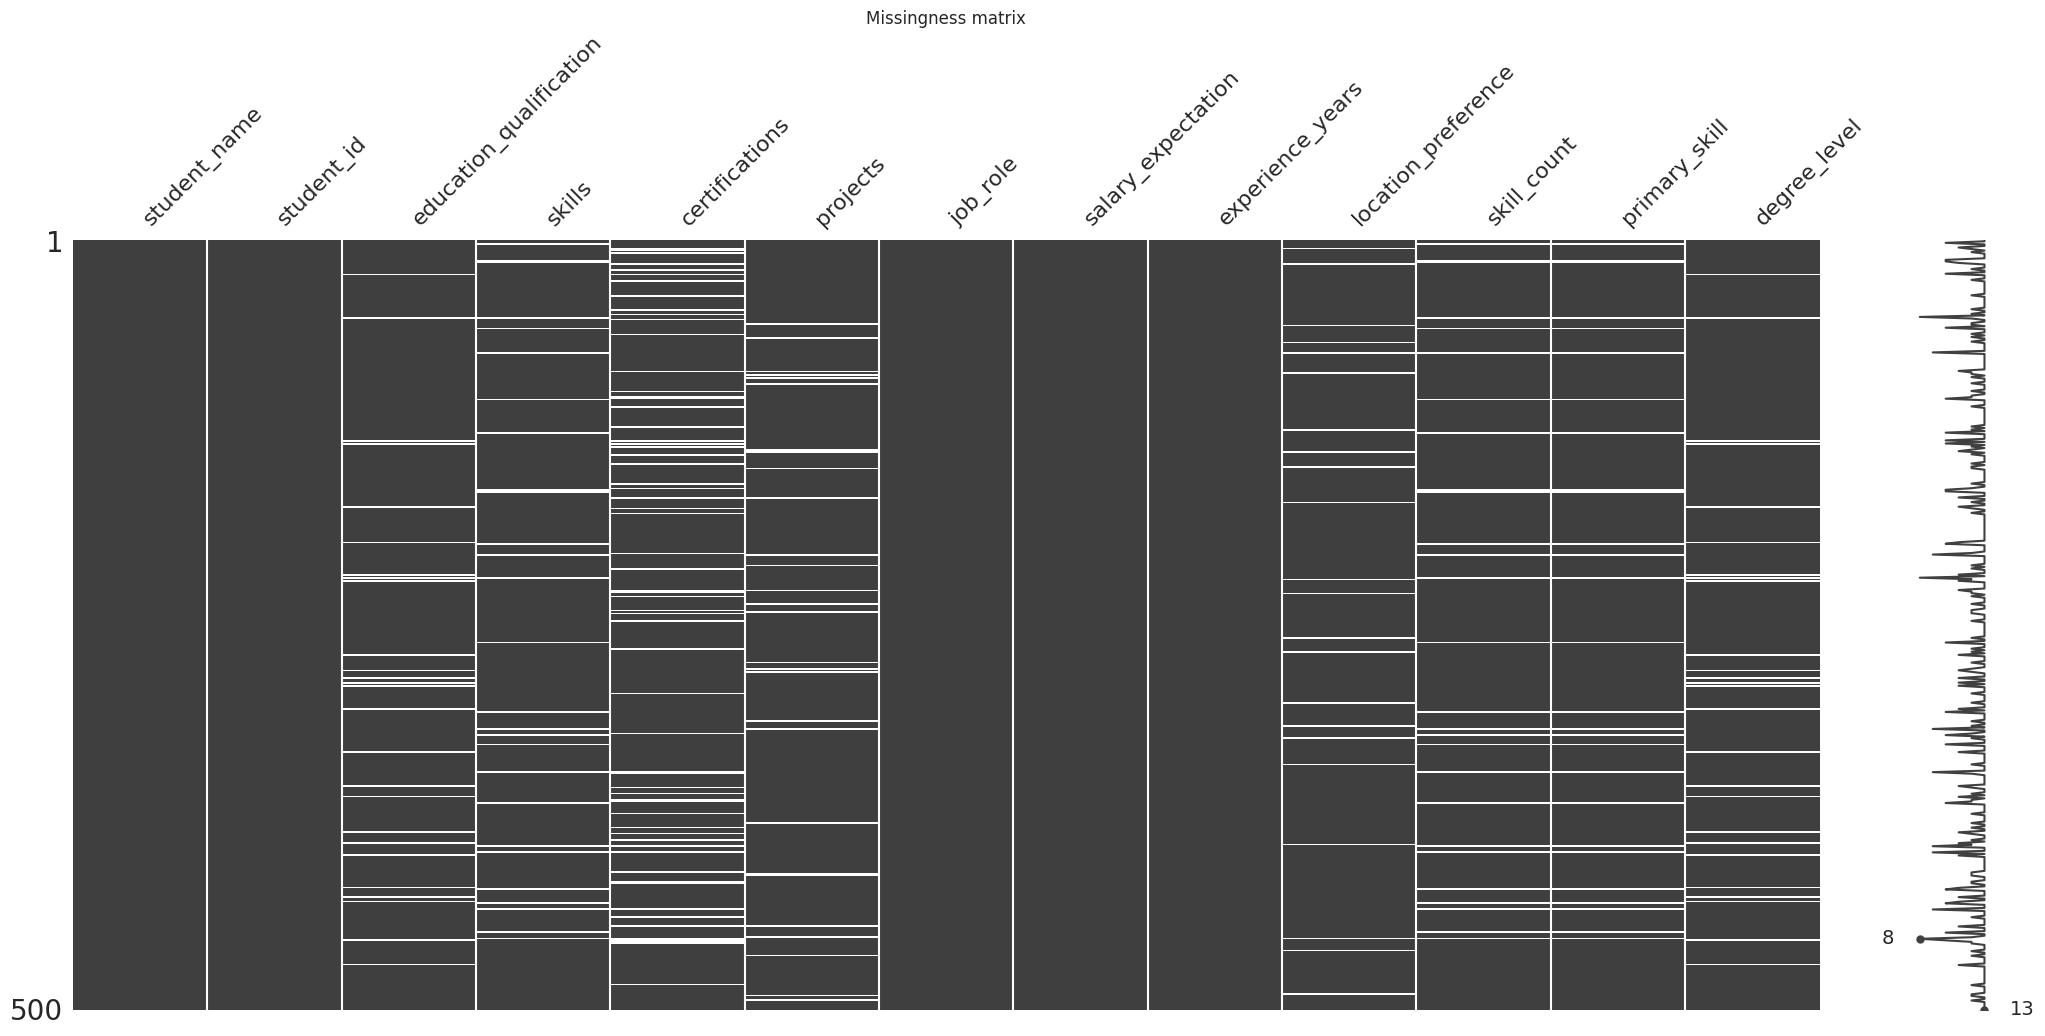

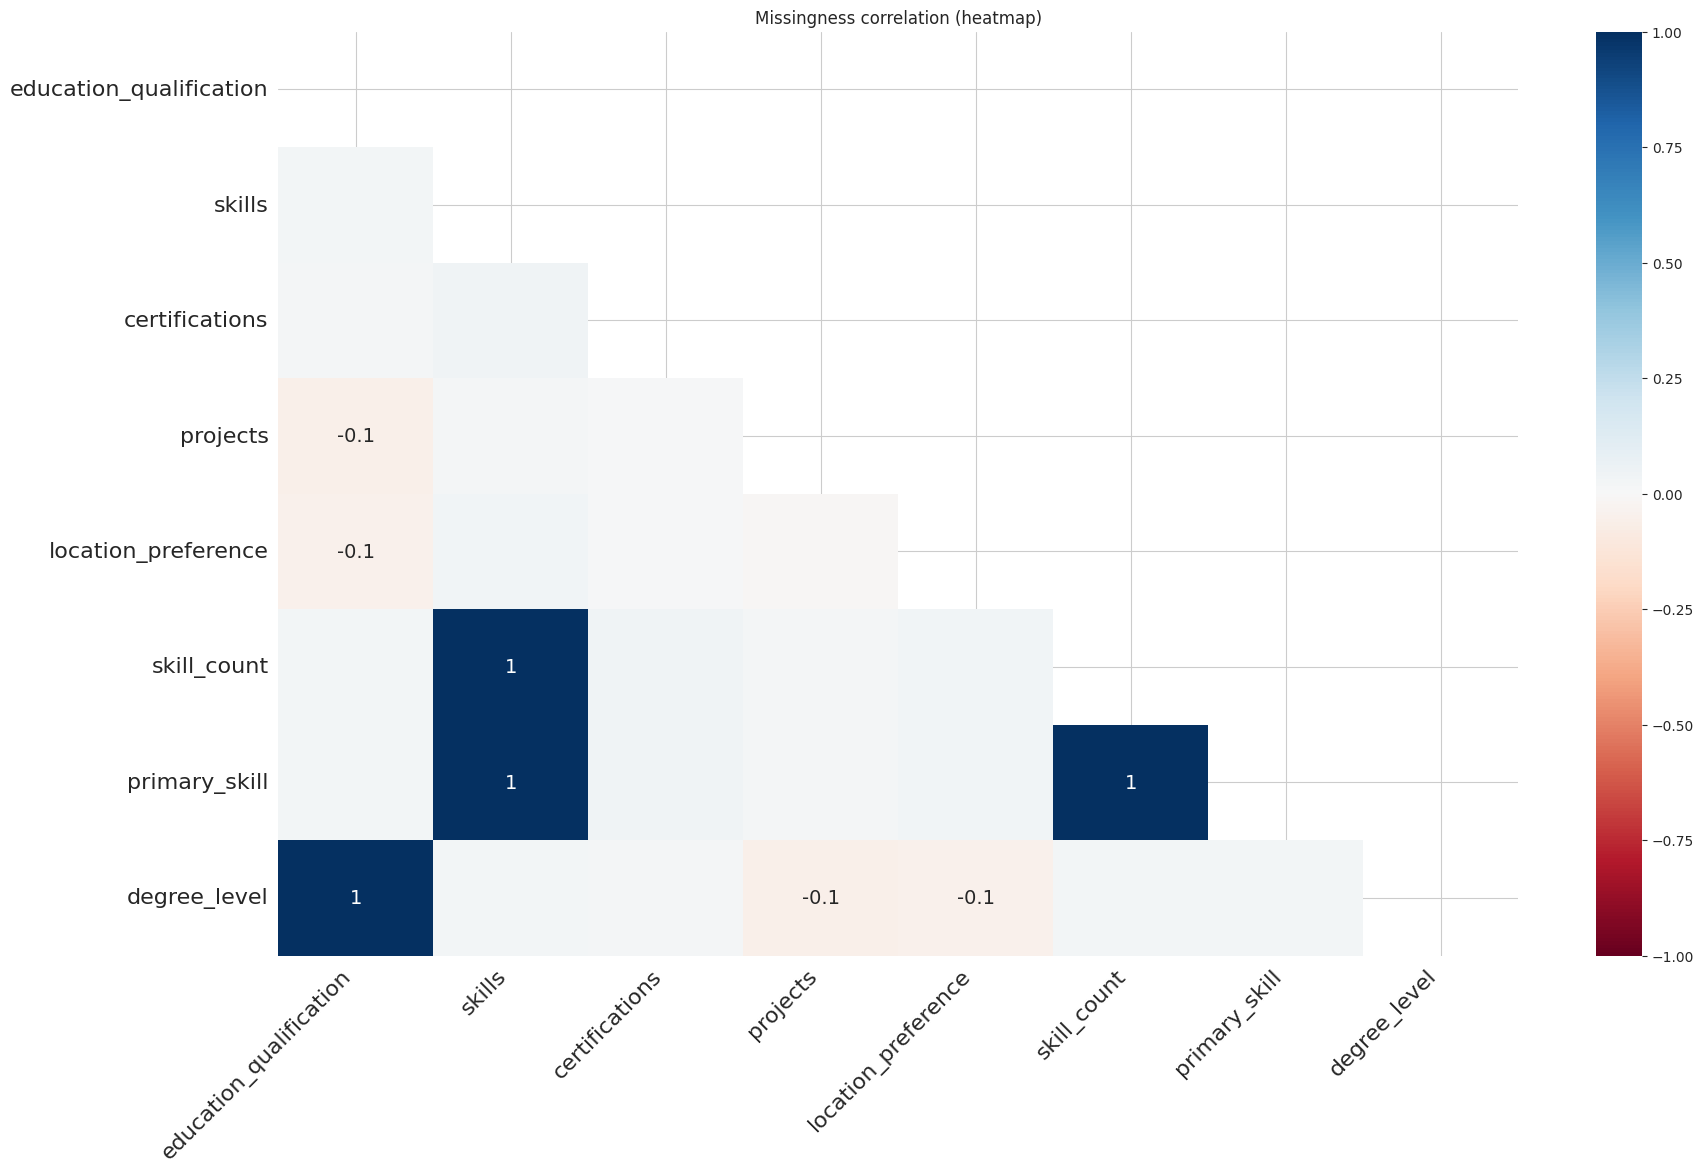

In [ ]:
# Visualize missingness
msno.matrix(df)
plt.title("Missingness matrix")
plt.show()

msno.heatmap(df)
plt.title("Missingness correlation (heatmap)")
plt.show()


In [ ]:
# 3) Column types and unique counts
print(df.dtypes)
print("\nUnique values per column:\n", df.nunique().sort_values(ascending=False))


student_name                object
student_id                  object
education_qualification     object
skills                      object
certifications              object
projects                    object
job_role                    object
salary_expectation         float64
experience_years             int64
location_preference         object
skill_count                float64
primary_skill               object
degree_level                object
dtype: object

Unique values per column:
 student_id                 500
salary_expectation          11
student_name                10
skills                      10
education_qualification     10
certifications              10
projects                    10
job_role                    10
location_preference         10
primary_skill                9
experience_years             5
degree_level                 3
skill_count                  2
dtype: int64


In [ ]:
# 4) Numeric column list
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols


['salary_expectation', 'experience_years', 'skill_count']

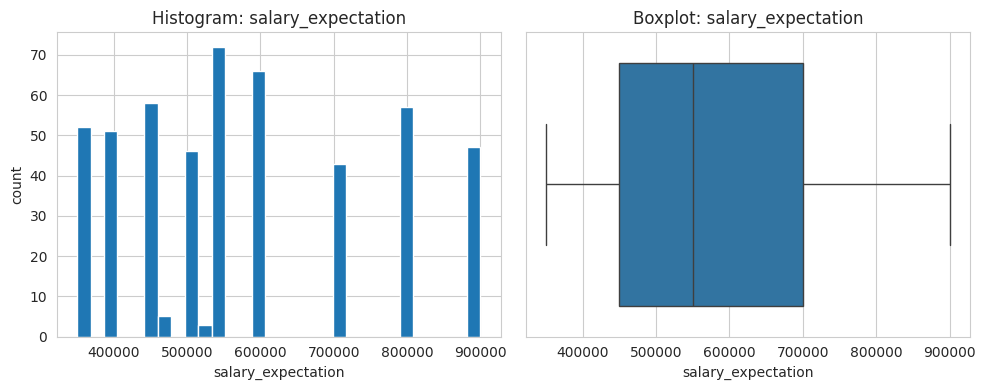

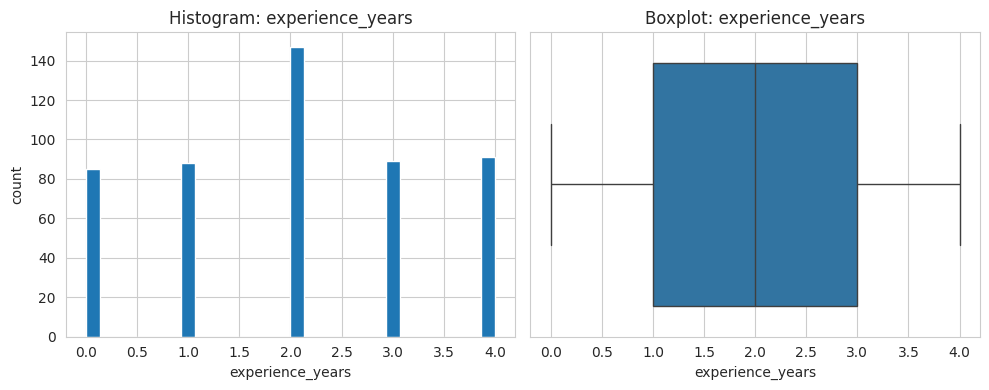

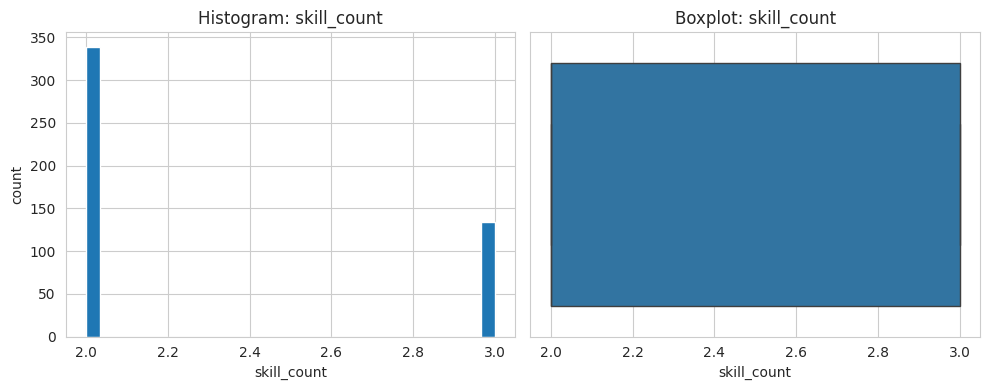

In [ ]:
# Summary and histograms
df[num_cols].describe().T
for c in num_cols:
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    df[c].hist(bins=30)
    plt.title(f"Histogram: {c}")
    plt.xlabel(c)
    plt.ylabel("count")

    plt.subplot(1,2,2)
    sns.boxplot(x=df[c])
    plt.title(f"Boxplot: {c}")
    plt.tight_layout()
    plt.show()


In [ ]:
# 5) Categorical columns
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
cat_cols


['student_name',
 'student_id',
 'education_qualification',
 'skills',
 'certifications',
 'projects',
 'job_role',
 'location_preference',
 'primary_skill',
 'degree_level']


Top categories for job_role:
job_role
AI Engineer             60
Data Analyst            56
Marketing Executive     55
Web Developer           55
HR Analyst              52
Data Scientist          48
Software Developer      48
Cloud Engineer          46
Full Stack Developer    41
Business Analyst        39
Name: count, dtype: int64


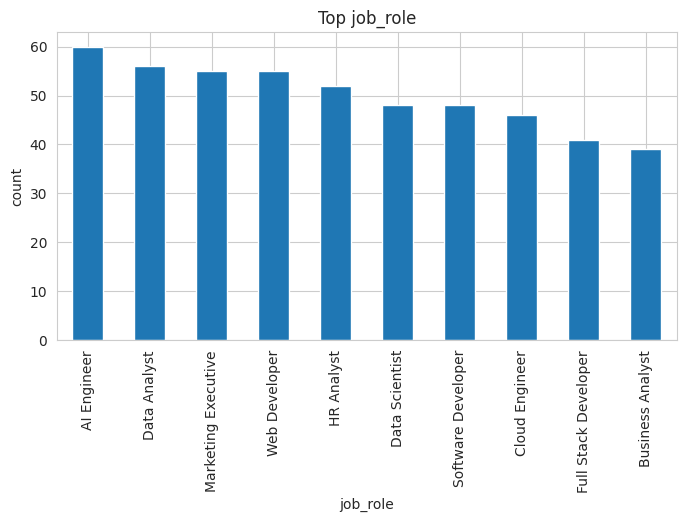


Top categories for degree_level:
degree_level
Bachelors    218
Masters      199
Other         57
NaN           26
Name: count, dtype: int64


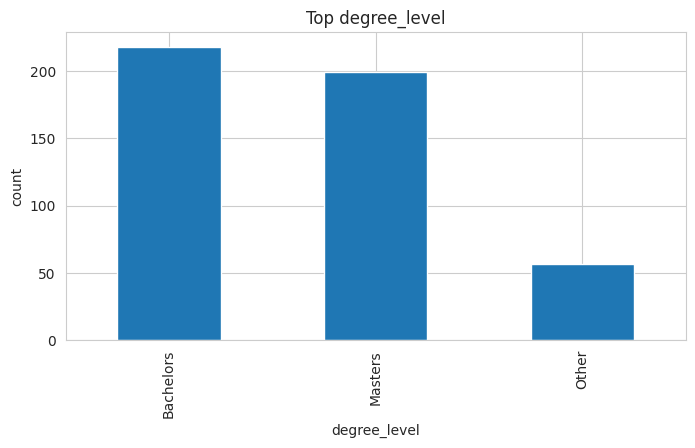


Top categories for primary_skill:
primary_skill
Python            87
Data Analytics    55
Cloud             53
Java              51
Ai                51
C++               49
React             49
Marketing         41
Management        37
NaN               27
Name: count, dtype: int64


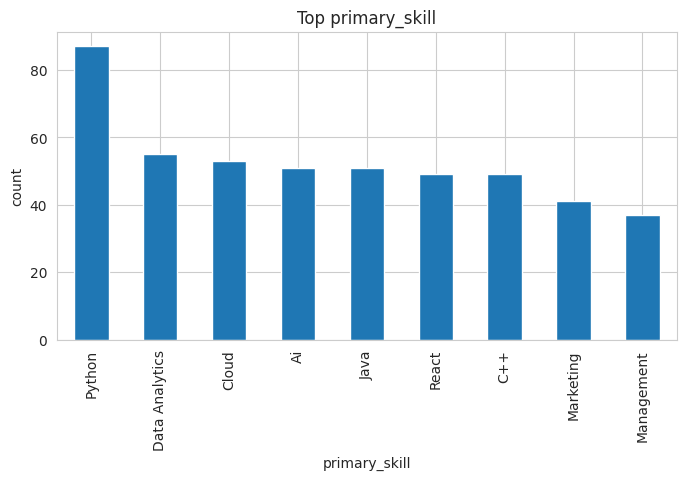


Top categories for location_preference:
location_preference
Remote       60
Pune         58
Delhi        56
Mumbai       54
Jaipur       51
Kolkata      43
Chennai      41
Ahmedabad    39
Hyderabad    39
Bangalore    37
NaN          22
Name: count, dtype: int64


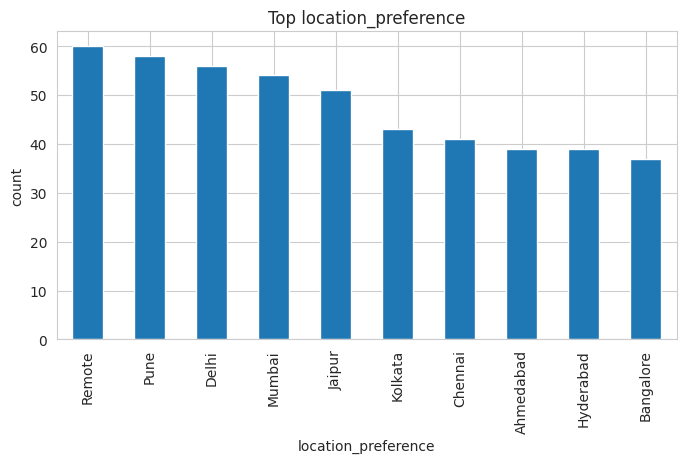

In [ ]:
# Value counts for key categorical columns
for c in ['job_role', 'degree_level', 'primary_skill', 'location_preference']:
    if c in df.columns:
        print(f"\nTop categories for {c}:")
        print(df[c].value_counts(dropna=False).head(20))
        # barplot (top 10)
        plt.figure(figsize=(8,4))
        df[c].value_counts().head(10).plot(kind='bar')
        plt.title(f"Top {c}")
        plt.ylabel("count")
        plt.show()


Top 20 skills:
 skills
Python            138
Excel              90
Ml                 85
Power Bi           55
Data Analytics     55
Cloud              53
Devops             53
Ai                 51
Java               51
Spring             51
Css                49
Node.Js            49
React              49
Html               49
C++                49
Sales              41
Marketing          41
Management         37
Sql                34
Name: count, dtype: int64


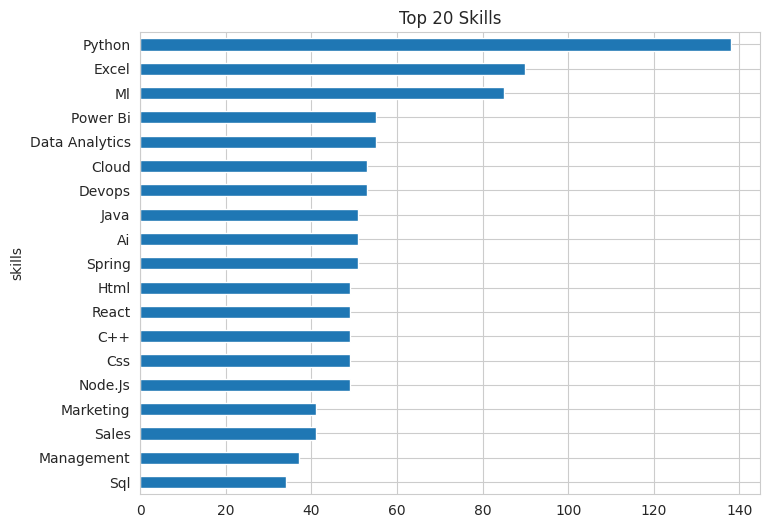

Top 20 certifications:
 certifications
Google Data Analytics     56
Excel Basics              55
Data Science With R       53
Java Foundations          46
Aws Cloud Practitioner    42
Azure Fundamentals        40
Digital Marketing         40
Leadership Basics         39
Python For Everyone       34
Ai Certification          33
Name: count, dtype: int64


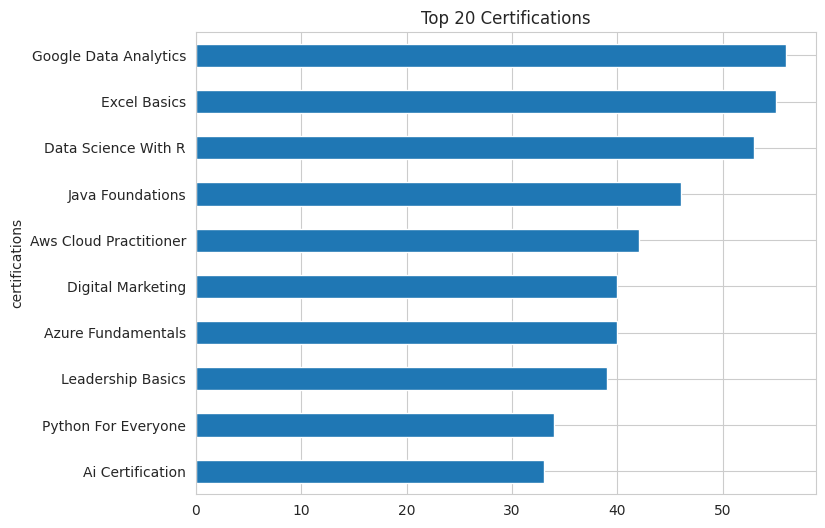

Top projects:
 projects
Customer Retention    60
Student Portal        60
Library Management    53
Sales Forecasting     47
E-Commerce Website    46
Market Analysis       46
Web Scraper           43
Data Dashboard        43
Hr Automation         38
Ai Chatbot            36
Name: count, dtype: int64


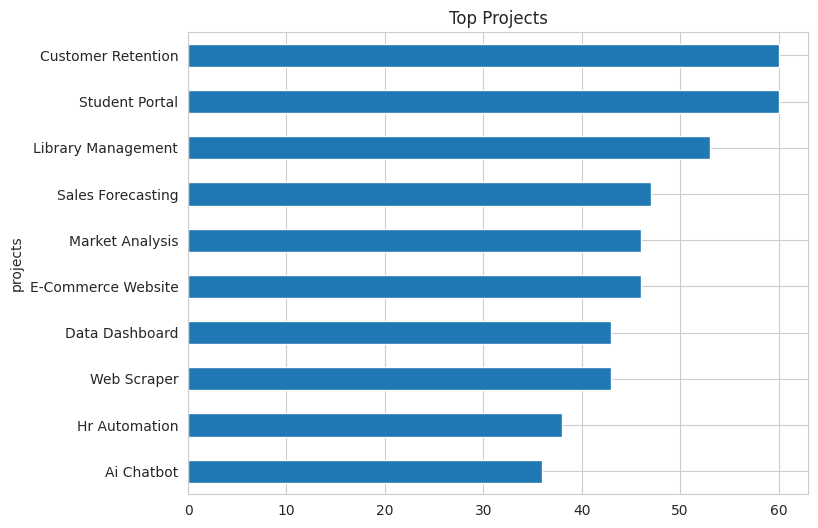

In [ ]:
# 6) Prepare exploded tables for skills, certifications, projects
def explode_count(df, colname, sep=","):
    s = df[[colname]].dropna().copy()
    s[colname] = s[colname].astype(str)
    s = s.assign(**{colname: s[colname].str.split(sep)})
    s = s.explode(colname)
    s[colname] = s[colname].str.strip().str.title()
    counts = s[colname].value_counts()
    return s, counts

# Skills
if 'skills' in df.columns:
    skills_exploded, skills_count = explode_count(df, 'skills')
    print("Top 20 skills:\n", skills_count.head(20))
    plt.figure(figsize=(8,6))
    skills_count.head(20).sort_values().plot(kind='barh')
    plt.title("Top 20 Skills")
    plt.show()

# Certifications
if 'certifications' in df.columns:
    certs_exploded, certs_count = explode_count(df, 'certifications')
    print("Top 20 certifications:\n", certs_count.head(20))
    plt.figure(figsize=(8,6))
    certs_count.head(20).sort_values().plot(kind='barh')
    plt.title("Top 20 Certifications")
    plt.show()

# Projects
if 'projects' in df.columns:
    proj_exploded, proj_count = explode_count(df, 'projects')
    print("Top projects:\n", proj_count.head(20))
    plt.figure(figsize=(8,6))
    proj_count.head(20).sort_values().plot(kind='barh')
    plt.title("Top Projects")
    plt.show()


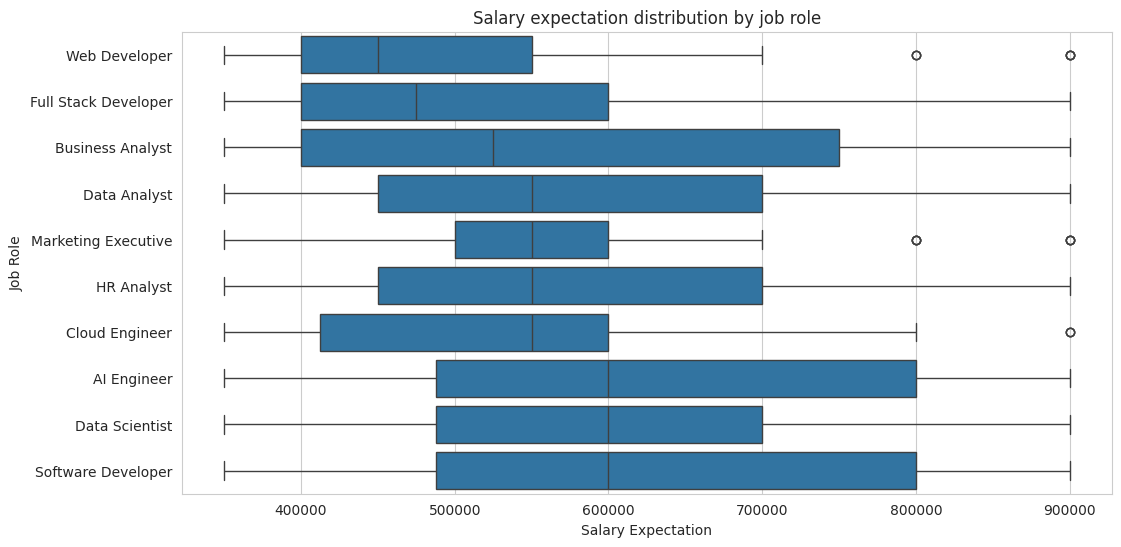

,count,median,mean,std,min,max
job_role,,,,,,
AI Engineer,60,600000.0,620833.333333,167557.646712,350000.0,900000.0
Data Scientist,48,600000.0,588541.666667,151320.282891,350000.0,900000.0
Software Developer,48,600000.0,634375.000000,187411.326550,350000.0,900000.0
Marketing Executive,55,550000.0,571818.181818,143618.461997,350000.0,900000.0
Data Analyst,56,550000.0,583035.714286,166044.020920,350000.0,900000.0
Cloud Engineer,46,550000.0,561956.521739,158529.626607,350000.0,900000.0
HR Analyst,52,550000.0,582692.307692,155577.549979,350000.0,900000.0
Business Analyst,39,525000.0,587820.512821,197922.748326,350000.0,900000.0
Full Stack Developer,41,475000.0,531097.560976,171280.151342,350000.0,900000.0


In [ ]:
# 7) Salary by job_role (boxplot) and summary stats
if 'salary_expectation' in df.columns and 'job_role' in df.columns:
    plt.figure(figsize=(12,6))
    sns.boxplot(y='job_role', x='salary_expectation', data=df, order=df.groupby('job_role')['salary_expectation'].median().sort_values().index)
    plt.title("Salary expectation distribution by job role")
    plt.xlabel("Salary Expectation")
    plt.ylabel("Job Role")
    plt.show()

    # Group stats
    sal_stats = df.groupby('job_role')['salary_expectation'].agg(['count','median','mean','std','min','max']).sort_values('median', ascending=False)
    display(sal_stats)


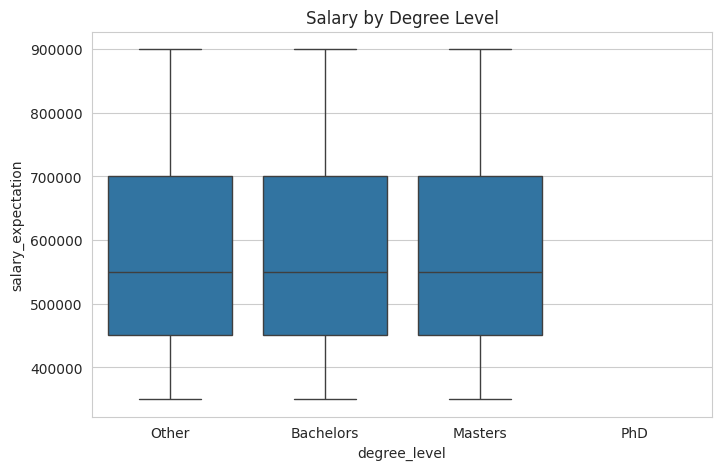

              count           mean            std       min       25%       50%       75%       max
degree_level                                                                                       
Bachelors     218.0  590940.366972  173091.731690  350000.0  450000.0  550000.0  700000.0  900000.0
Masters       199.0  561683.417085  162072.453172  350000.0  450000.0  550000.0  700000.0  900000.0
Other          57.0  582456.140351  161325.765166  350000.0  450000.0  550000.0  700000.0  900000.0


In [ ]:
# Salary vs degree_level
if 'degree_level' in df.columns and 'salary_expectation' in df.columns:
    plt.figure(figsize=(8,5))
    sns.boxplot(x='degree_level', y='salary_expectation', data=df, order=['Other','Bachelors','Masters','PhD'])
    plt.title("Salary by Degree Level")
    plt.show()

    print(df.groupby('degree_level')['salary_expectation'].describe())


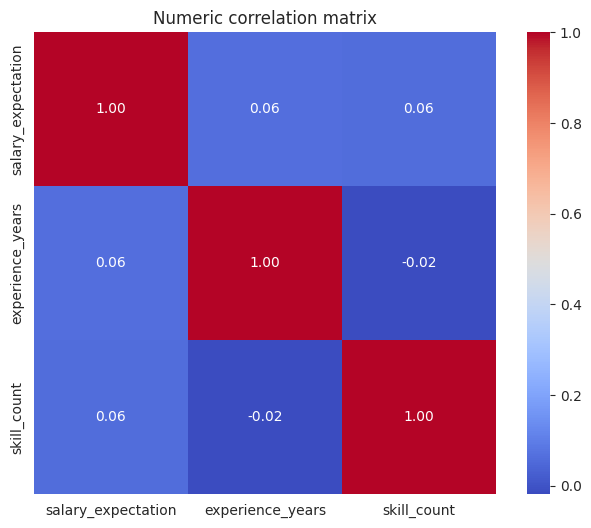

In [ ]:
# 8) Correlations
num = df.select_dtypes(include=[np.number])
corr = num.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Numeric correlation matrix")
plt.show()


In [ ]:
# 9) Detect outliers using IQR for salary_expectation
if 'salary_expectation' in df.columns:
    col = 'salary_expectation'
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    print(f"{col} IQR bounds: lower={lower}, upper={upper}")
    df['salary_outlier'] = ((df[col] < lower) | (df[col] > upper))
    print("Outlier count:", df['salary_outlier'].sum())
    display(df[df['salary_outlier']].head(10))


salary_expectation IQR bounds: lower=75000.0, upper=1075000.0
Outlier count: 0


,student_name,student_id,education_qualification,skills,certifications,projects,job_role,salary_expectation,experience_years,location_preference,skill_count,primary_skill,degree_level,salary_outlier


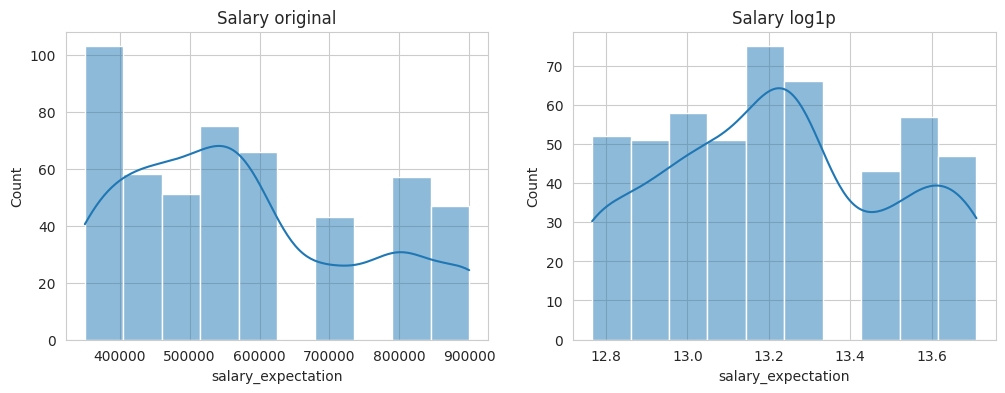

In [ ]:
# 10) Log transform salary if heavily skewed
if 'salary_expectation' in df.columns:
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1); sns.histplot(df['salary_expectation'].dropna(), kde=True); plt.title("Salary original")
    plt.subplot(1,2,2); sns.histplot(np.log1p(df['salary_expectation'].dropna()), kde=True); plt.title("Salary log1p")
    plt.show()
    df['salary_log'] = np.log1p(df['salary_expectation'])


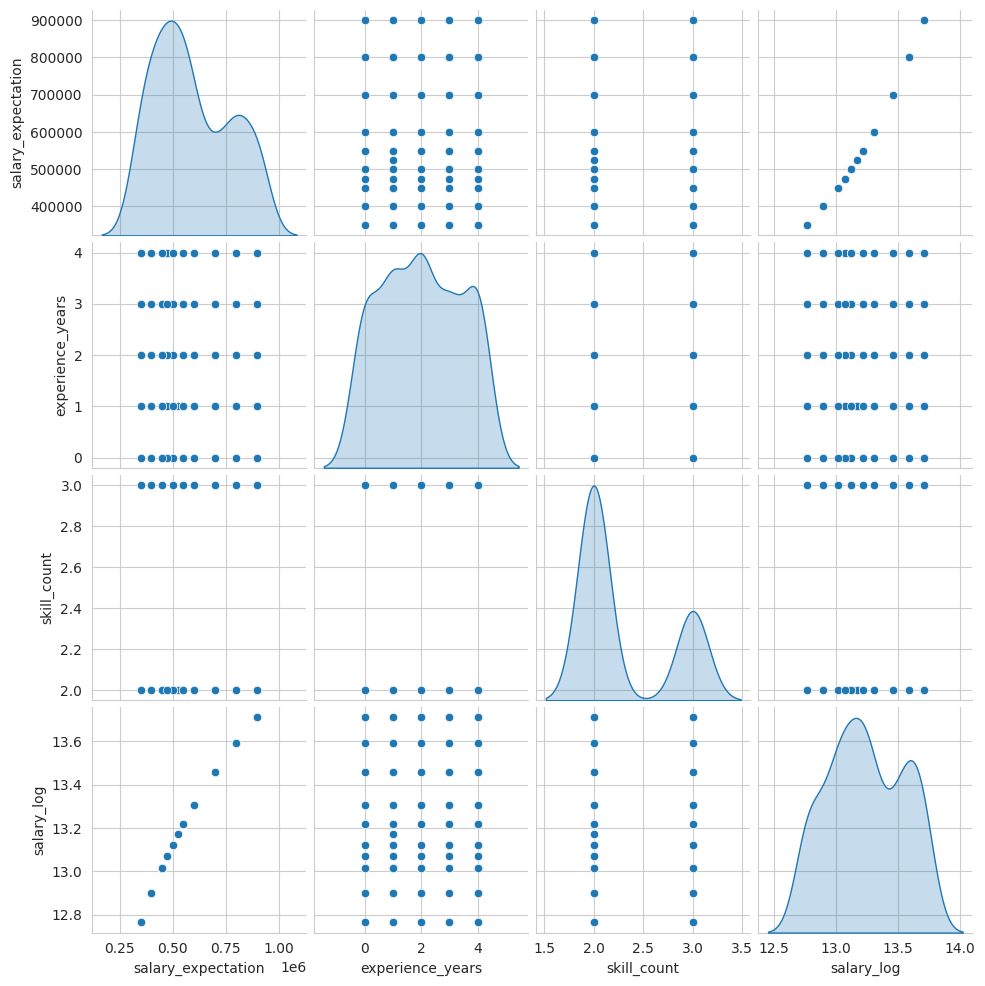

In [ ]:
# 11) Pairplot for numeric features (use sample to keep it fast)
num_small = df.select_dtypes(include=[np.number]).drop(columns=['salary_outlier'], errors='ignore')
if num_small.shape[1] > 1:
    sns.pairplot(num_small.sample(min(200, len(num_small))), diag_kind='kde')
    plt.show()


In [ ]:
# 12) Pivot: median salary by job_role and degree_level
if set(['job_role','degree_level','salary_expectation']).issubset(df.columns):
    pivot = pd.pivot_table(df, index='job_role', columns='degree_level', values='salary_expectation', aggfunc='median')
    display(pivot)


degree_level,Bachelors,Masters,Other
job_role,,,
AI Engineer,600000.0,600000.0,700000.0
Business Analyst,700000.0,475000.0,625000.0
Cloud Engineer,550000.0,550000.0,500000.0
Data Analyst,575000.0,550000.0,550000.0
Data Scientist,600000.0,600000.0,600000.0
Full Stack Developer,450000.0,487500.0,625000.0
HR Analyst,600000.0,500000.0,575000.0
Marketing Executive,550000.0,550000.0,550000.0
Software Developer,600000.0,600000.0,800000.0


In [ ]:
# Crosstab: primary_skill vs job_role (top pairs)
if 'primary_skill' in df.columns and 'job_role' in df.columns:
    ct = pd.crosstab(df['primary_skill'], df['job_role'])
    display(ct.loc[ct.sum(axis=1).sort_values(ascending=False).index[:20]])  # top 20 skills rows


job_role,AI Engineer,Business Analyst,Cloud Engineer,Data Analyst,Data Scientist,Full Stack Developer,HR Analyst,Marketing Executive,Software Developer,Web Developer
primary_skill,,,,,,,,,,
Python,11,8,5,9,8,4,13,12,8,9
Data Analytics,4,5,6,8,3,4,3,5,8,9
Cloud,2,4,4,6,4,6,5,8,9,5
Ai,10,2,7,2,4,3,7,6,5,5
Java,5,3,5,5,9,6,4,8,2,4
C++,9,2,6,5,6,3,4,2,4,8
React,2,10,7,4,3,3,6,6,3,5
Marketing,3,2,3,4,5,6,4,5,3,6
Management,6,2,3,6,4,2,5,2,4,3


In [ ]:
# 13) Create simple text-based features
for c in ['projects','certifications']:
    if c in df.columns:
        df[f'{c}_len'] = df[c].astype(str).fillna('').apply(lambda x: len(x))
        df[f'{c}_tokens'] = df[c].astype(str).fillna('').apply(lambda x: len(x.split(',')) if x else 0)

df[['projects_len','projects_tokens','certifications_len','certifications_tokens']].head()


,projects_len,projects_tokens,certifications_len,certifications_tokens
0,18,1,19,1
1,18,1,16,1
2,18,1,21,1
3,10,1,16,1
4,14,1,12,1


In [ ]:
# 14) Save cleaned+augmented dataframe and basic reports
df.to_csv("student_job_role_dataset_500_eda.csv", index=False)
print("Saved augmented dataset: student_job_role_dataset_500_eda.csv")

# Save a CSV of top skills, certs, projects
skills_count.head(200).to_csv("top_skills.csv")
certs_count.head(200).to_csv("top_certifications.csv")
proj_count.head(200).to_csv("top_projects.csv")
print("Saved top skills/certs/projects CSVs.")


Saved augmented dataset: student_job_role_dataset_500_eda.csv
Saved top skills/certs/projects CSVs.


In [ ]:
from google.colab import files
files.download("student_job_role_dataset_500_eda.csv")
files.download("top_skills.csv")
files.download("top_certifications.csv")
files.download("top_projects.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Load cleaned dataset
df = pd.read_csv("student_job_role_dataset_500_eda.csv")

# Display first few rows
df.head()

,student_name,student_id,education_qualification,skills,certifications,projects,job_role,salary_expectation,experience_years,location_preference,skill_count,primary_skill,degree_level,salary_outlier,salary_log,projects_len,projects_tokens,certifications_len,certifications_tokens
0,Ravi Singh,S196,MBA,"Marketing, Sales",Data Science with R,E-commerce Website,Business Analyst,900000.0,3,Ahmedabad,2.0,Marketing,Masters,False,13.710151,18,1,19,1
1,Sneha Patel,S080,B.Com,"Python, Excel",Java Foundations,E-commerce Website,Web Developer,450000.0,2,Chennai,2.0,Python,Bachelors,False,13.017005,18,1,16,1
2,Ankit Mehta,S481,B.Tech ECE,NaN,Google Data Analytics,Library Management,Business Analyst,450000.0,0,Mumbai,NaN,NaN,Bachelors,False,13.017005,18,1,21,1
3,Rahul Verma,S110,B.Com,"Python, Excel",AI Certification,AI Chatbot,Data Scientist,450000.0,2,Pune,2.0,Python,Bachelors,False,13.017005,10,1,16,1
4,Neha Gupta,S281,B.Tech ECE,"Management, Excel",Excel Basics,Student Portal,AI Engineer,400000.0,4,Delhi,2.0,Management,Bachelors,False,12.899222,14,1,12,1


In [ ]:
# Drop missing job roles
df = df.dropna(subset=['job_role'])

# Fill missing text-based columns with empty strings
for col in ['skills', 'certifications', 'education_qualification', 'projects']:
    df[col] = df[col].fillna('')

# Reset index
df = df.reset_index(drop=True)


In [ ]:
# Combine education, skills, certifications, and projects into one text column
df['combined_text'] = (
    df['education_qualification'] + ' ' +
    df['skills'] + ' ' +
    df['certifications'] + ' ' +
    df['projects']
)


In [ ]:
X = df['combined_text']     # Input features (text)
y = df['job_role']          # Target variable


In [ ]:
# Encode job roles as numeric labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

dict(zip(le.classes_, range(len(le.classes_))))


{'AI Engineer': 0,
 'Business Analyst': 1,
 'Cloud Engineer': 2,
 'Data Analyst': 3,
 'Data Scientist': 4,
 'Full Stack Developer': 5,
 'HR Analyst': 6,
 'Marketing Executive': 7,
 'Software Developer': 8,
 'Web Developer': 9}

In [ ]:
# Convert text to numerical form using TF-IDF
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
X_tfidf = tfidf.fit_transform(X)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)


In [ ]:
# Train Logistic Regression Model
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)


LogisticRegression(max_iter=1000, random_state=42)

Because the target is a set of categorical job roles, I used Logistic Regression in a One-vs-Rest setup for multiclass classification. Inputs: the TF-IDF representation of the combined text. I split the data 80/20 and trained the model on the training set

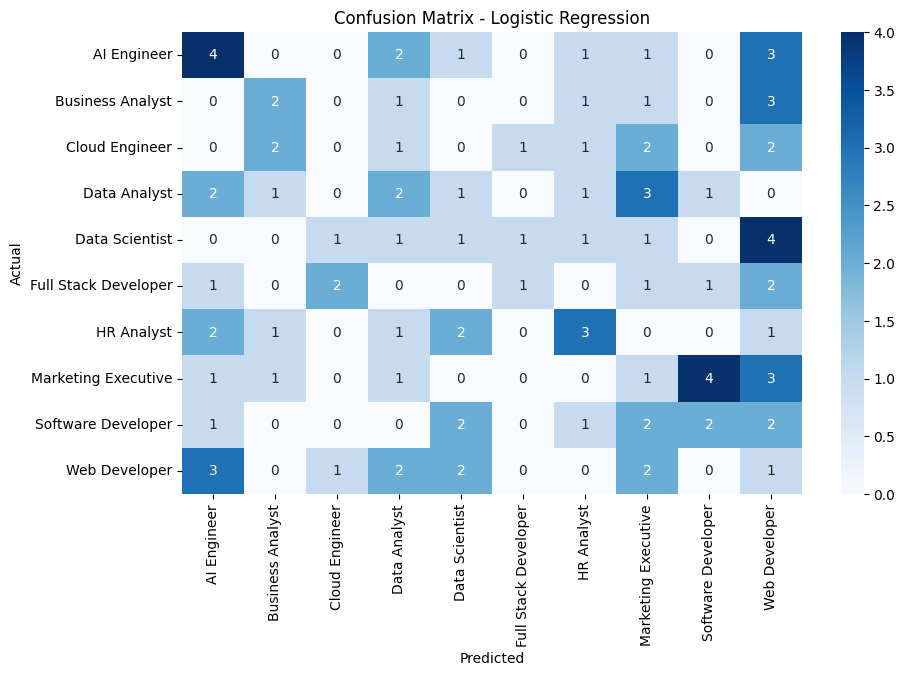

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


In [ ]:
import pickle

# Save trained model
pickle.dump(log_reg, open("job_role_logistic_model.pkl", "wb"))

# Save TF-IDF vectorizer
pickle.dump(tfidf, open("tfidf_vectorizer.pkl", "wb"))

print("✅ Model and vectorizer saved successfully!")


✅ Model and vectorizer saved successfully!


## Visualization

In [ ]:

!pip install scikit-plot --quiet
!pip install shap --quiet


In [ ]:
# Imports used across the following cells
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, LabelBinarizer, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc, roc_auc_score, confusion_matrix, accuracy_score
from sklearn.calibration import calibration_curve
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import PartialDependenceDisplay
from sklearn.multiclass import OneVsRestClassifier


In [ ]:
# 1) Load cleaned data and prepare text + target
df = pd.read_csv("student_job_role_dataset_500_cleaned.csv")
df = df.dropna(subset=['job_role']).reset_index(drop=True)

# Basic fill for text columns
for col in ['education_qualification','skills','certifications','projects']:
    if col in df.columns:
        df[col] = df[col].fillna('').astype(str)

# combined text
df['combined_text'] = df['education_qualification'] + ' ' + df['skills'] + ' ' + df['certifications'] + ' ' + df['projects']

X_text = df['combined_text']
y = df['job_role']

# Encode labels
le = LabelEncoder()
y_enc = le.fit_transform(y)   # numeric labels
class_names = le.classes_

# Train/test split
X_train_text, X_test_text, y_train_enc, y_test_enc = train_test_split(
    X_text, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

# TF-IDF + Logistic (One-vs-Rest)
tfidf = TfidfVectorizer(stop_words='english', max_features=3000)
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

# One-vs-Rest LogisticRegression (gives probability for each class)
ovr_clf = OneVsRestClassifier(LogisticRegression(max_iter=1000, solver='lbfgs'))
ovr_clf.fit(X_train_tfidf, y_train_enc)

# Predict probabilities
y_score = ovr_clf.predict_proba(X_test_tfidf)
print("TF-IDF logistic (OvR) trained. Num classes:", len(class_names))


TF-IDF logistic (OvR) trained. Num classes: 10


/tmp/ipython-input-2242191911.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20').colors


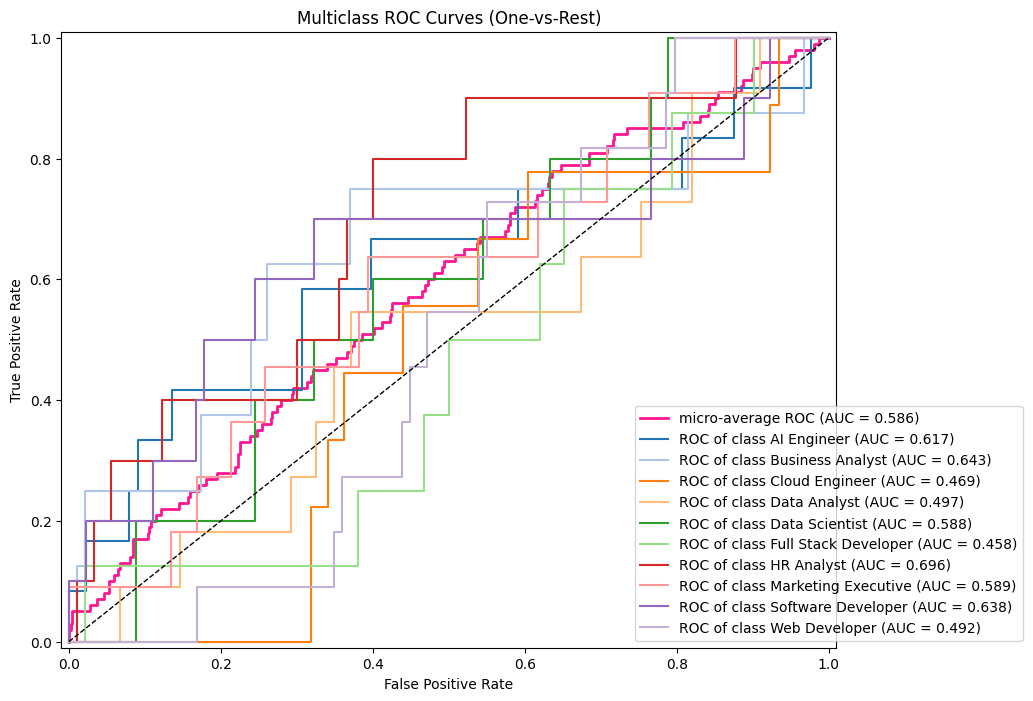

In [ ]:
# 2) Multiclass ROC curves (One-vs-Rest)
# Binarize true labels for ROC computation
lb = LabelBinarizer()
y_test_binarized = lb.fit_transform(y_test_enc)  # shape (n_samples, n_classes)

if y_test_binarized.ndim == 1:
    y_test_binarized = np.vstack([1 - y_test_binarized, y_test_binarized]).T

# Compute per-class ROC and AUC
fpr = dict(); tpr = dict(); roc_auc = dict()
n_classes = y_test_binarized.shape[1]
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and AUC
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_binarized.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot
plt.figure(figsize=(10, 8))
plt.plot(fpr["micro"], tpr["micro"],
         label='micro-average ROC (AUC = {0:0.3f})'.format(roc_auc["micro"]), color='deeppink', linewidth=2)

colors = plt.cm.get_cmap('tab20').colors
for i, color in enumerate(colors[:n_classes]):
    plt.plot(fpr[i], tpr[i], color=color, lw=1.5,
             label='ROC of class {0} (AUC = {1:0.3f})'.format(class_names[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curves (One-vs-Rest)')
plt.legend(loc='lower right', bbox_to_anchor=(1.25, 0))
plt.show()


## **Visualization: Multiclass ROC Curves (One-vs-Rest)**

ROC curves for each job role. Because this is multiclass, I trained a One-vs-Rest Logistic Regression and computed an ROC curve for each class versus all others.

## **Axes :-**
X-axis is False Positive Rate, Y-axis is True Positive Rate. A curve closer to the top-left corner and AUC near 1.0 means the model discriminates that class well.

### Explanation :-  
1. The micro-average curve summarizes overall performance across classes.

2. For each class, point to its curve and state its AUC: e.g., ‘Data Analyst has AUC = 0.88, meaning strong discrimination’.

3. If any class has an AUC near 0.5, that suggests the model struggles to distinguish that class.

4. We expect some classes with similar descriptions (e.g., Data Analyst vs Business Analyst) to have slightly lower AUC because their text features overlap.

5. Classes with specialized keywords (e.g., ‘AI’, ‘Deep Learning’) usually show higher AUC.

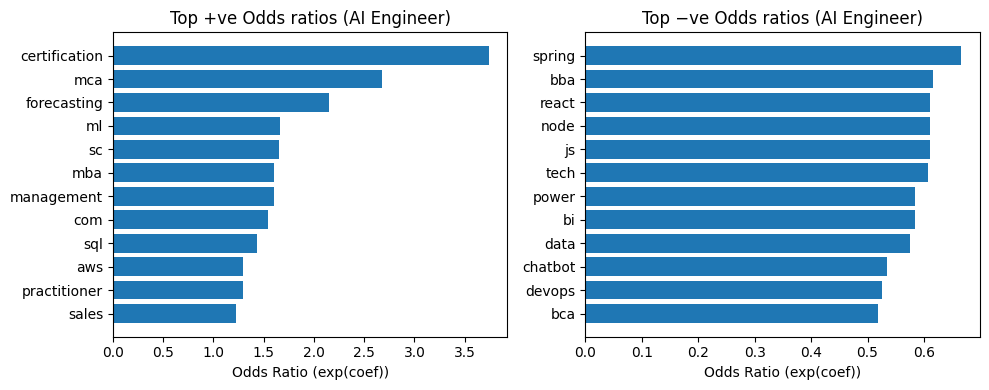

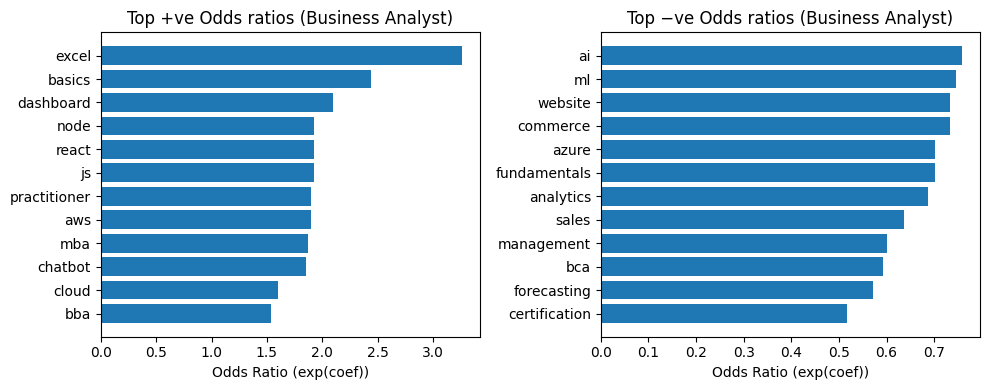

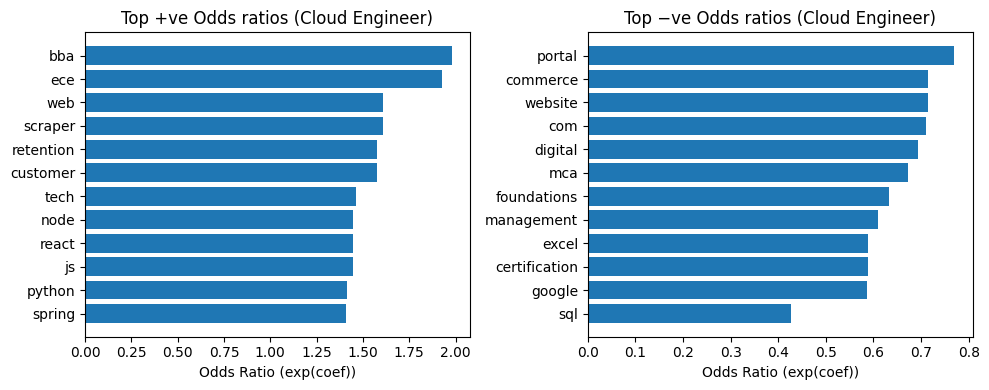

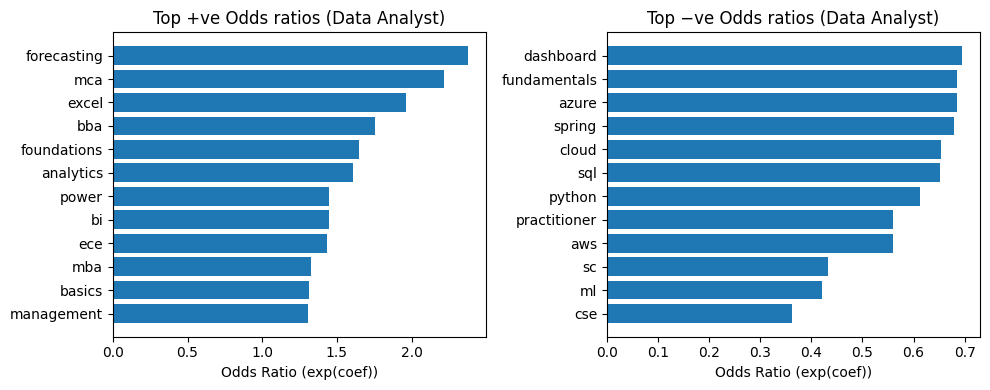

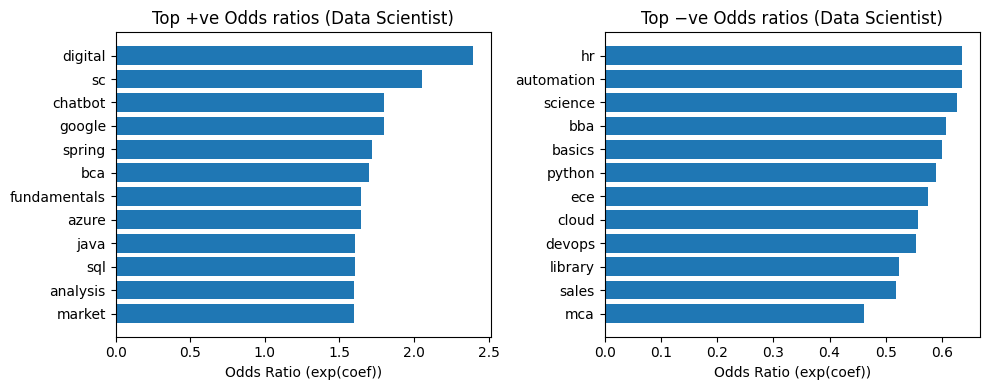

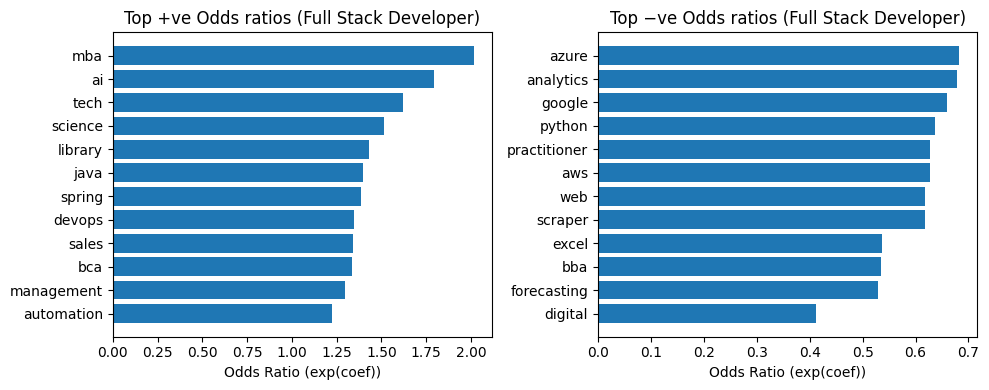

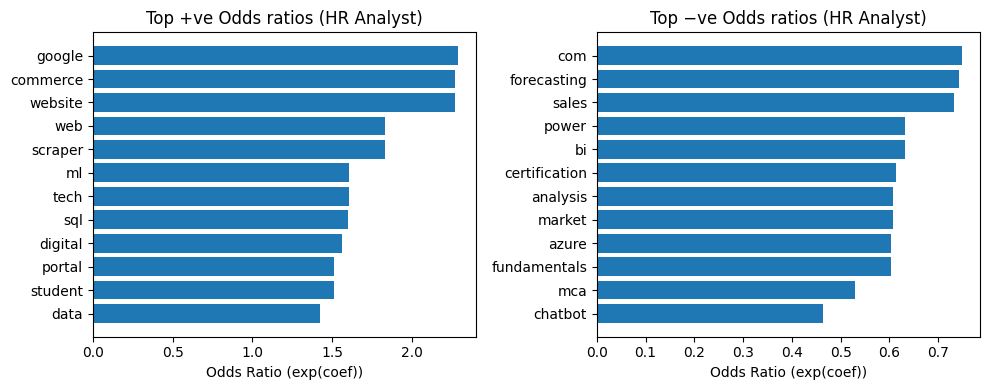

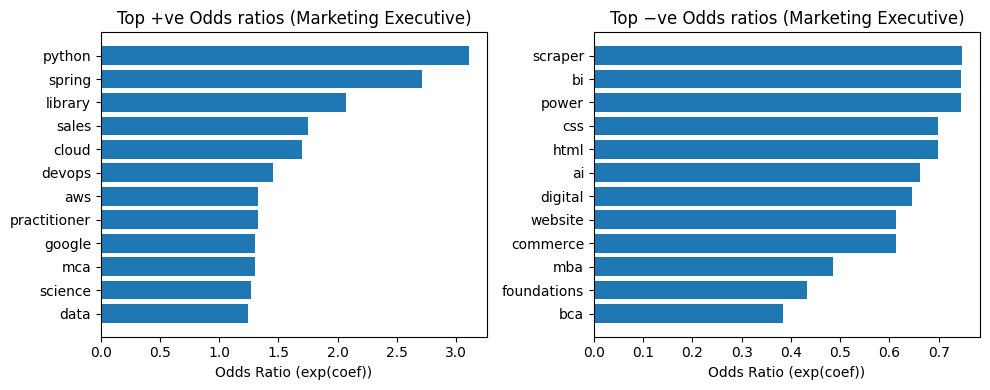

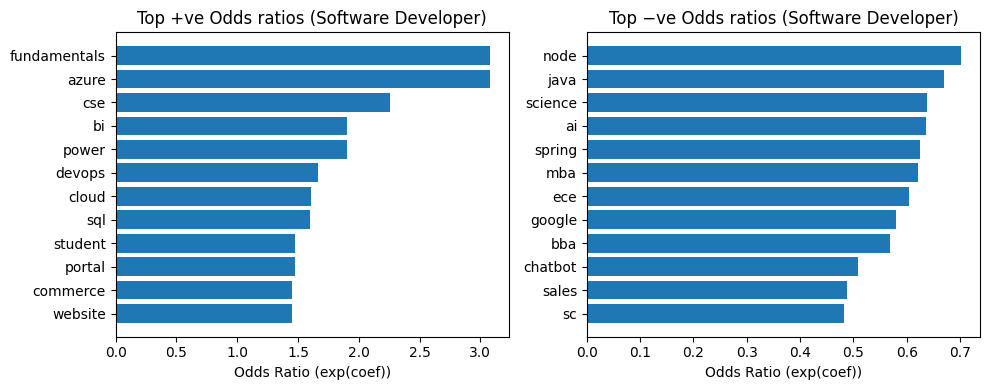

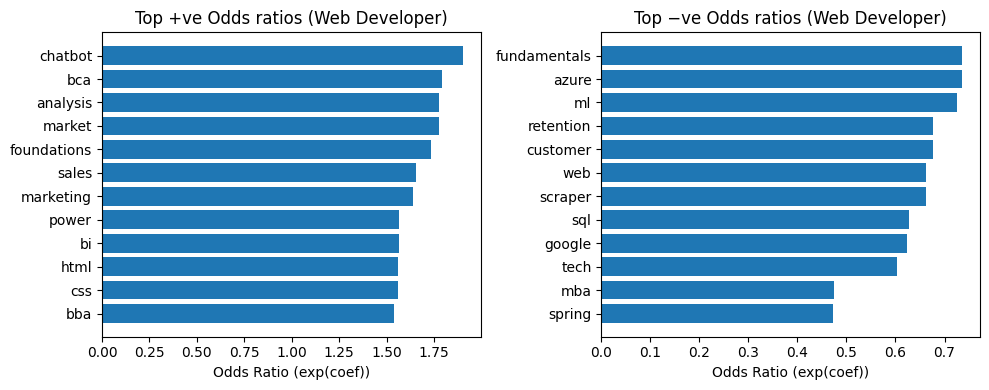

In [ ]:
# 3) Odds Ratio (Top features per class)
# Get feature names from TF-IDF
feature_names = np.array(tfidf.get_feature_names_out())

# For OneVsRestClassifier, coef_ is (n_classes, n_features)
coefs = ovr_clf.estimators_[0].coef_ if hasattr(ovr_clf.estimators_[0], 'coef_') else None
coefs_all = np.vstack([est.coef_.ravel() for est in ovr_clf.estimators_])  # shape (n_classes, n_features)

# For each class: get top positive and negative coefficient feature
top_n = 12
for i, cls in enumerate(class_names):
    coef = coefs_all[i]
    # Odds ratio = exp(coef)
    odds = np.exp(coef)
    # Top positive features
    top_pos_idx = np.argsort(coef)[-top_n:][::-1]
    top_neg_idx = np.argsort(coef)[:top_n]
    top_pos_feats = feature_names[top_pos_idx]
    top_neg_feats = feature_names[top_neg_idx]

    # Plot top positive and negative odds (as bars)
    plt.figure(figsize=(10,4))
    vals_pos = odds[top_pos_idx]
    plt.subplot(1,2,1)
    plt.barh(top_pos_feats[::-1], vals_pos[::-1])
    plt.title(f"Top +ve Odds ratios ({cls})")
    plt.xlabel("Odds Ratio (exp(coef))")

    vals_neg = odds[top_neg_idx]
    plt.subplot(1,2,2)
    plt.barh(feature_names[top_neg_idx], vals_neg)
    plt.title(f"Top −ve Odds ratios ({cls})")
    plt.xlabel("Odds Ratio (exp(coef))")
    plt.tight_layout()
    plt.show()


## **Visualization: Odds Ratio Plots (Top features per class)**

For Logistic Regression, exponentiating coefficients gives odds ratios. An odds ratio > 1 means the presence of that token increases the odds of the class; < 1 means it decreases the odds

### Explanation :-  
1. Left chart shows top positive tokens — words that strongly increase likelihood of this class. For example, if ‘python’ has OR = 2.5 for Data Analyst, that means presence of ‘python’ multiplies the odds of ‘Data Analyst’ by 2.5.

2. Right chart shows top negative tokens — words whose presence reduces the odds for the class (OR < 1)

3. For Data Analyst you may see tokens like ‘python’, ‘sql’, ‘pandas’ as top positive tokens.

4. For Web Developer, expect ‘html’, ‘css’, ‘javascript’ as positive tokens.

5. This helps validate the model — it learns sensible associations.

6. These odds ratios are useful for explaining the model to non-technical stakeholders — they show which keywords drive a prediction.

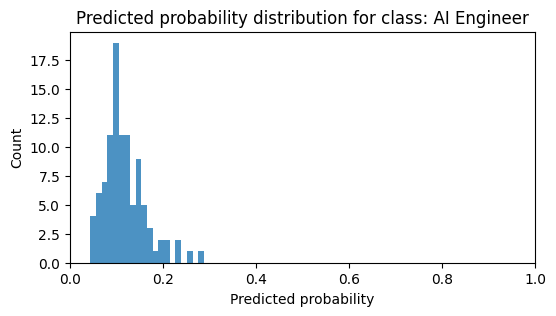

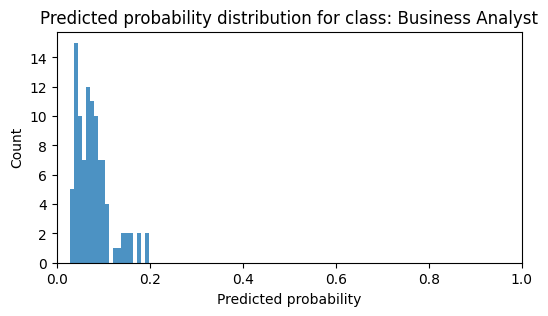

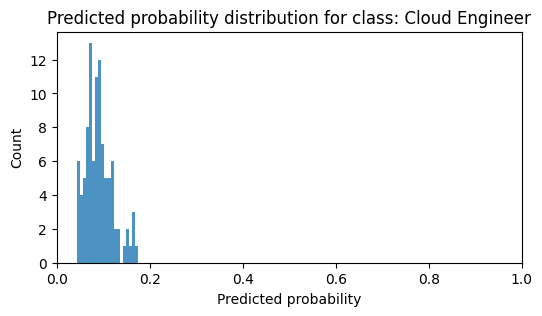

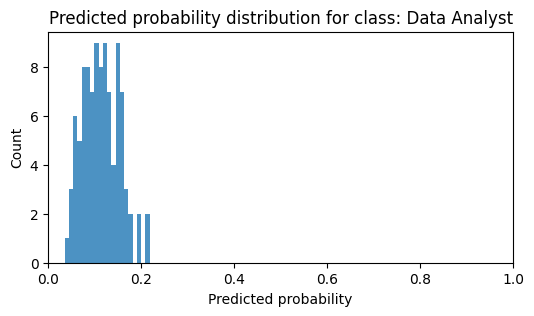

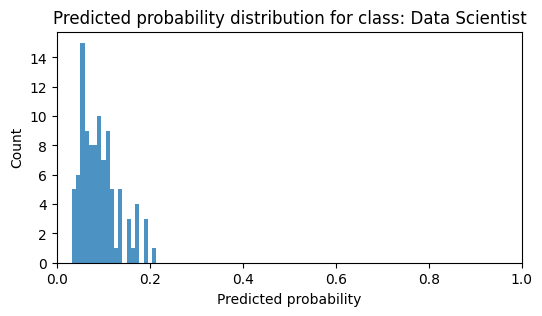

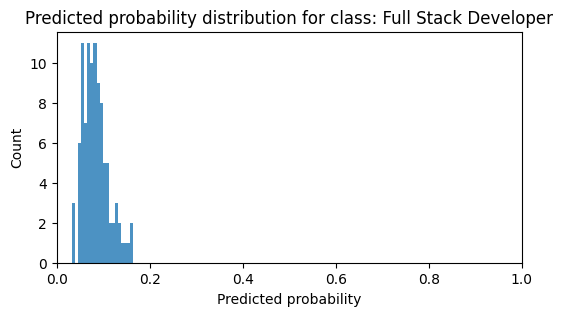

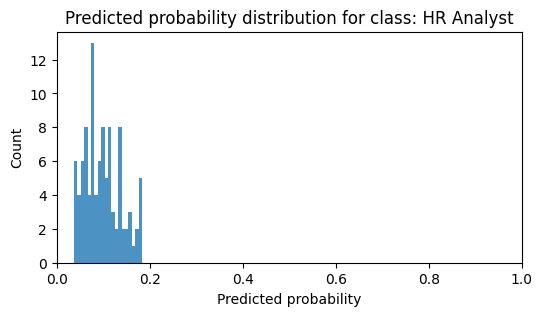

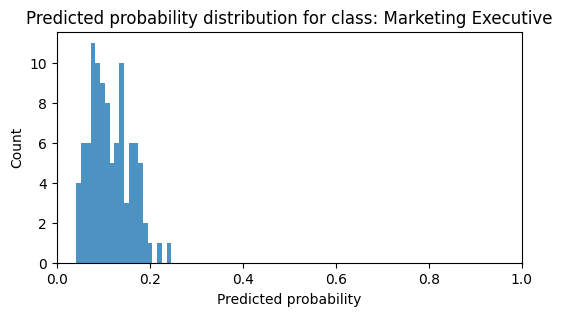

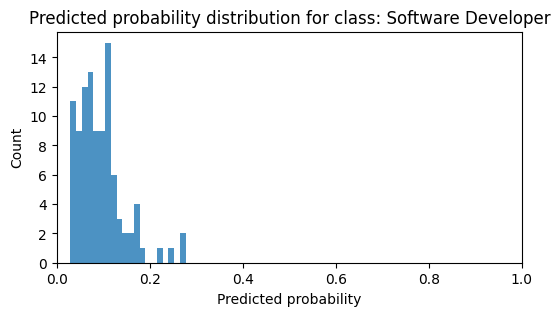

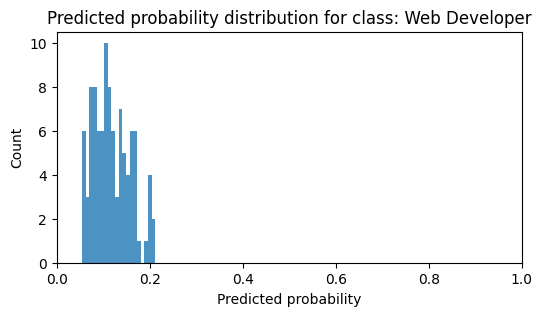

In [ ]:
# 4a) Histogram of predicted probabilities per class
y_proba = y_score  # shape (n_samples, n_classes) from earlier

for i, cls in enumerate(class_names):
    plt.figure(figsize=(6,3))
    plt.hist(y_proba[:, i], bins=20, alpha=0.8)
    plt.title(f"Predicted probability distribution for class: {cls}")
    plt.xlabel("Predicted probability")
    plt.ylabel("Count")
    plt.xlim(0,1)
    plt.show()


## **Visualization: Predicted Probability Distributions (per class)**

Histogram (or violin/box) of predicted probabilities for each class, plus calibration curve for 2–3 classes.

### Explanation :-  
1. This plot shows the distribution of predicted probabilities for each class on the test set. It answers: how confident is the model when it assigns probability to a class.

2. If probabilities cluster near 1 for correct class instances and near 0 for incorrect ones, the model is confident and calibrated.

3. If many probabilities are around 0.4–0.6, model confidence is low.

4. Calibration plots compare predicted probability to observed fraction positive. If the curve follows the diagonal, predicted probabilities reflect true likelihoods — the model is well calibrated.

5. Probability distributions + calibration help decide whether to rely on predicted probabilities for downstream decisions (e.g., show top-3 job suggestions when top-1 is low confidence).



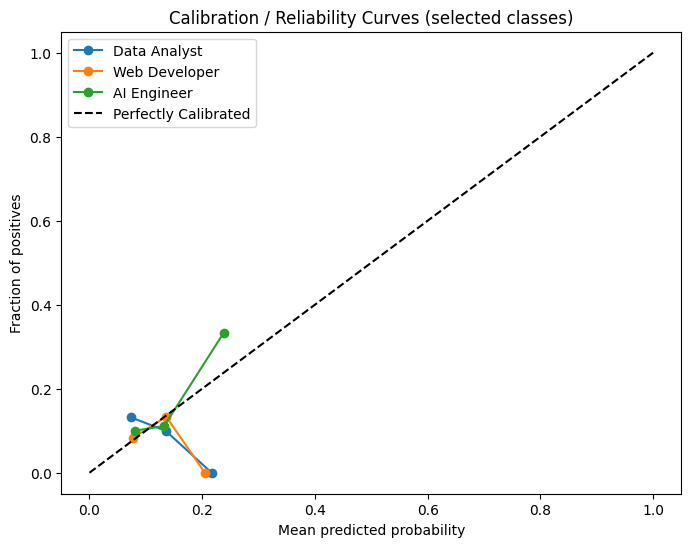

In [ ]:
# 4b) Calibration / reliability curve (one class example and micro-average)
from sklearn.calibration import calibration_curve

# We'll plot for a few selected classes (top 3 frequent classes)
top_classes_idx = np.argsort(np.bincount(y_test_enc))[-3:]  # indices of top 3 frequent classes in test
plt.figure(figsize=(8,6))
for i in top_classes_idx:
    prob_true, prob_pred = calibration_curve(y_test_binarized[:, i], y_proba[:, i], n_bins=10)
    plt.plot(prob_pred, prob_true, marker='o', label=f"{class_names[i]}")

plt.plot([0,1],[0,1],'k--', label='Perfectly Calibrated')
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title("Calibration / Reliability Curves (selected classes)")
plt.legend()
plt.show()


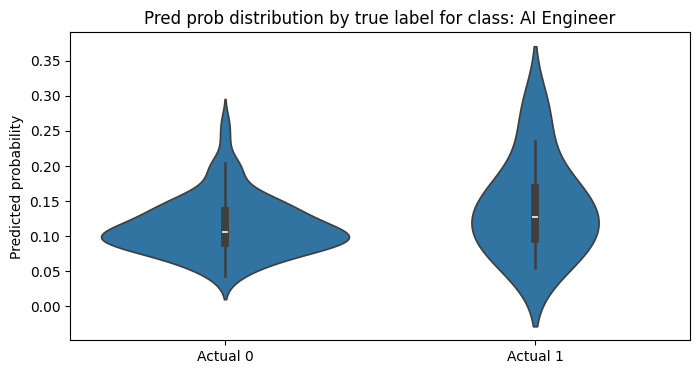

In [ ]:
# 4c) Predicted probability vs true label scatter for one class (example)
cls_idx = 0  # change index to visualize other classes
plt.figure(figsize=(8,4))
sns.violinplot(x=y_test_binarized[:, cls_idx], y=y_proba[:, cls_idx])
plt.xticks([0,1], ['Actual 0','Actual 1'])
plt.ylabel("Predicted probability")
plt.title(f"Pred prob distribution by true label for class: {class_names[cls_idx]}")
plt.show()
